# 02 - User-item interactions

Load australian_users_items.json, flatten into a tidy (user_id, item_id, playtime) table, and do basic coverage checks.

Field reference (from australian_users_items.json):
- user_id, steam_id, user_url, items_count
- items: [{item_id, item_name, playtime_forever, playtime_2weeks}]

This feeds into notebook 03, where we build the bundle demand proxies.

> **Legacy descriptive artifact.** This notebook preserves the original display-alias/keep-first table used by notebooks 03--08. The live Stage 1 cycle instead uses numeric `steam_id` and fieldwise-maximum duplicate consolidation in `src/stage1_source_interactions.py`. A 2026-08-14 audit found identical 5,094,082 ownership edges; only 10 playtime rows changed (+217 lifetime minutes and +203 two-week minutes in total). Ownership results in notebooks 03--05 and all live Stage 1 results are therefore unaffected. A future descriptive-v2 cycle should rebuild these legacy tables rather than overwrite them silently.

In [ ]:
import os, ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_RAW = '../data/raw'

## Load australian_users_items.json

Note: this file is 527 MB, so it takes a little while to load.

In [2]:
user_items_path = os.path.join(DATA_RAW, 'australian_users_items.json')

raw_users = []
with open(user_items_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            raw_users.append(ast.literal_eval(line))

print(f'loaded {len(raw_users):,} user records')
print('\nfirst record (non-list fields):')
import json
first = raw_users[0]
sensitive = {'user_id', 'steam_id', 'user_url'}
public_first = {
    k: ('[redacted]' if k in sensitive else v)
    for k, v in first.items() if not isinstance(v, list)
}
print(json.dumps(public_first, indent=2))
print('\nfirst item in first record:', first['items'][0])


loaded 88,310 user records

first record (non-list fields):
{
  "user_id": "[redacted]",
  "items_count": 277,
  "steam_id": "[redacted]",
  "user_url": "[redacted]"
}

first item in first record: {'item_id': '10', 'item_name': 'Counter-Strike', 'playtime_forever': 6, 'playtime_2weeks': 0}


## Flatten into user_items_df

In [3]:
rows = []
for rec in raw_users:
    user_id = rec.get('user_id') or rec.get('steam_id')
    for item in rec.get('items', []):
        rows.append({
            'user_id':          str(user_id),
            'item_id':          str(item.get('item_id', '')),
            'item_name':        item.get('item_name'),
            'playtime_forever': item.get('playtime_forever', 0),
            'playtime_2weeks':  item.get('playtime_2weeks', 0),
        })

user_items_df = pd.DataFrame(rows)

# the raw file has some duplicate (user_id, item_id) pairs -- drop them
n_before = len(user_items_df)
user_items_df = user_items_df.drop_duplicates(subset=['user_id', 'item_id'])
n_dropped = n_before - len(user_items_df)
if n_dropped > 0:
    print(f'dropped {n_dropped:,} duplicate (user_id, item_id) rows')

print('user_items_df shape:', user_items_df.shape)
print(user_items_df.drop(columns='user_id').head(5))

dropped 59,127 duplicate (user_id, item_id) rows
user_items_df shape: (5094082, 5)
  item_id                  item_name  playtime_forever  \
0      10             Counter-Strike                 6   
1      20      Team Fortress Classic                 0   
2      30              Day of Defeat                 7   
3      40         Deathmatch Classic                 0   
4      50  Half-Life: Opposing Force                 0   

   playtime_2weeks  
0                0  
1                0  
2                0  
3                0  
4                0  


## Coverage stats

In [4]:
n_users = user_items_df['user_id'].nunique()
n_items = user_items_df['item_id'].nunique()
n_rows = len(user_items_df)
# removing the same user-game pair

print(f'unique users:  {n_users:,}')
print(f'unique games:  {n_items:,}')
print(f'ownership records: {n_rows:,}')
print(f'avg games per user: {n_rows / n_users:.1f}')
print(f'avg users per game: {n_rows / n_items:.1f}')
print(f'playtime_forever == 0: {(user_items_df["playtime_forever"] == 0).sum():,} '
      f'({100*(user_items_df["playtime_forever"] == 0).mean():.1f}%)')


unique users:  70,912
unique games:  10,978
ownership records: 5,094,082
avg games per user: 71.8
avg users per game: 464.0
playtime_forever == 0: 1,847,730 (36.3%)


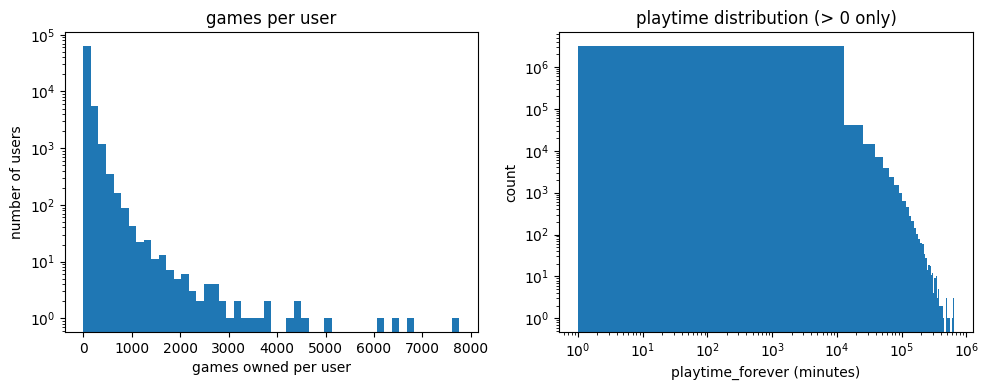

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

games_per_user = user_items_df.groupby('user_id')['item_id'].count()
axes[0].hist(games_per_user, bins=50)
axes[0].set_xlabel('games owned per user')
axes[0].set_ylabel('number of users')
axes[0].set_title('games per user')
axes[0].set_yscale('log')

pt = user_items_df.loc[user_items_df['playtime_forever'] > 0, 'playtime_forever']
axes[1].hist(pt, bins=50)
axes[1].set_xlabel('playtime_forever (minutes)')
axes[1].set_ylabel('count')
axes[1].set_title('playtime distribution (> 0 only)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('../outputs/figures/02_user_item_distributions.png')
plt.show()

In [6]:
user_items_df.to_csv('../outputs/tables/user_items_df.csv', index=False)
print('saved user_items_df.csv')


saved user_items_df.csv
